In [ ]:
!pip install numpy pandas scikit-learn

STEP 1: LOADING AND UNDERSTANDING THE DATASET
Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

DATA VISUALIZATION - UNDERSTANDING THE DATA


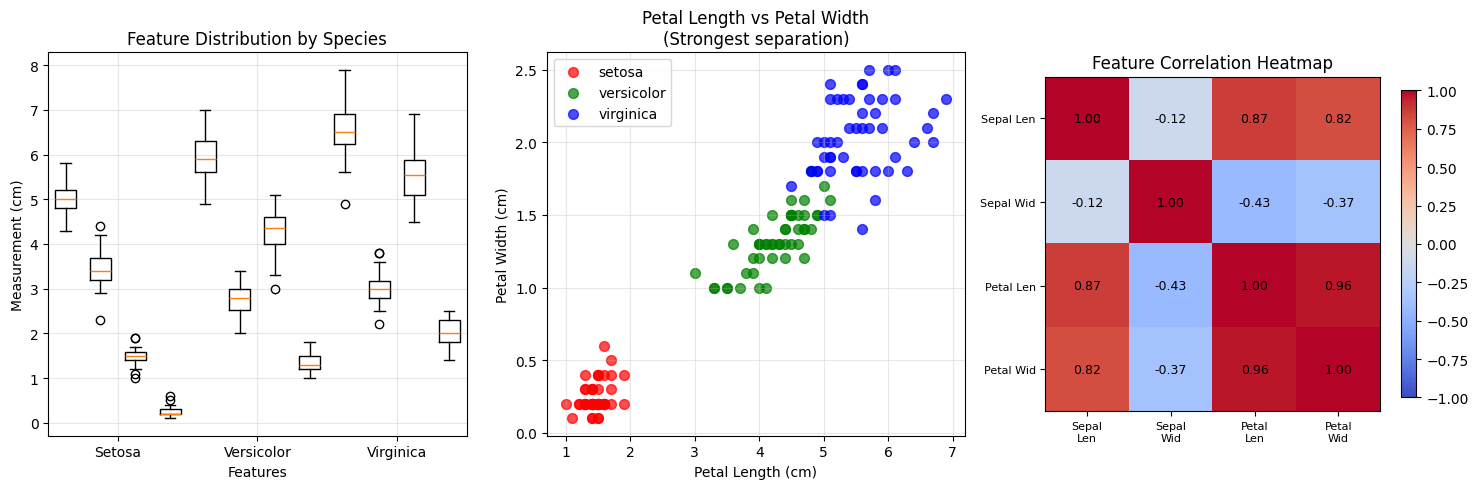


📊 INTERPRETATION OF GRAPHS:
1. Box Plot: Shows how each feature varies across the 3 flower species
2. Scatter Plot: Petal features clearly separate the species (good for classification)
3. Heatmap: Shows which features are correlated (petal length & width are highly correlated)

STEP 2: SPLITTING DATA (80% TRAIN, 20% TEST)
Training set size: 120 samples
Testing set size: 30 samples

STEP 3: TRAINING THE CLASSIFICATION MODEL
Model trained successfully!

STEP 4: MAKING PREDICTIONS & EVALUATION
Model Accuracy: 96.67%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

PREDICTI

In [ ]:
# ========== PROJECT 2: DATA CLASSIFICATION ==========

# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load and understand the dataset
print("=" * 50)
print("STEP 1: LOADING AND UNDERSTANDING THE DATASET")
print("=" * 50)

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nClass distribution:\n{df['species'].value_counts()}")
print(f"\nFeatures: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

# ========== DATA VISUALIZATION (3 GRAPHS) ==========
print("\n" + "=" * 50)
print("DATA VISUALIZATION - UNDERSTANDING THE DATA")
print("=" * 50)

# Set style for better looking graphs
plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graph 1: Distribution of each feature by species (Box Plot)
ax1 = axes[0]
for i, species in enumerate(iris.target_names):
    species_data = df[df['species'] == species]
    ax1.boxplot([species_data['sepal length (cm)'],
                  species_data['sepal width (cm)'],
                  species_data['petal length (cm)'],
                  species_data['petal width (cm)']],
                 positions=[i*4 + j for j in range(4)], widths=0.6)
ax1.set_xlabel('Features', fontsize=10)
ax1.set_ylabel('Measurement (cm)', fontsize=10)
ax1.set_title('Feature Distribution by Species', fontsize=12)
ax1.set_xticks([1.5, 5.5, 9.5])
ax1.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'])
ax1.grid(True, alpha=0.3)

# Graph 2: Scatter plot - Petal Length vs Petal Width
ax2 = axes[1]
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
for species, color in colors.items():
    species_data = df[df['species'] == species]
    ax2.scatter(species_data['petal length (cm)'],
                species_data['petal width (cm)'],
                c=color, label=species, alpha=0.7, s=50)
ax2.set_xlabel('Petal Length (cm)', fontsize=10)
ax2.set_ylabel('Petal Width (cm)', fontsize=10)
ax2.set_title('Petal Length vs Petal Width\n(Strongest separation)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graph 3: Correlation Heatmap
ax3 = axes[2]
correlation_matrix = df[['sepal length (cm)', 'sepal width (cm)',
                          'petal length (cm)', 'petal width (cm)']].corr()
im = ax3.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax3.set_xticks(range(4))
ax3.set_yticks(range(4))
ax3.set_xticklabels(['Sepal\nLen', 'Sepal\nWid', 'Petal\nLen', 'Petal\nWid'], fontsize=8)
ax3.set_yticklabels(['Sepal Len', 'Sepal Wid', 'Petal Len', 'Petal Wid'], fontsize=8)
ax3.set_title('Feature Correlation Heatmap', fontsize=12)

# Add colorbar
plt.colorbar(im, ax=ax3, shrink=0.8)

# Add numbers in correlation cells
for i in range(4):
    for j in range(4):
        text = ax3.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION OF GRAPHS:")
print("1. Box Plot: Shows how each feature varies across the 3 flower species")
print("2. Scatter Plot: Petal features clearly separate the species (good for classification)")
print("3. Heatmap: Shows which features are correlated (petal length & width are highly correlated)")

# Step 3: Split data into training and testing sets (80% train, 20% test)
print("\n" + "=" * 50)
print("STEP 2: SPLITTING DATA (80% TRAIN, 20% TEST)")
print("=" * 50)

X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target (species)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Step 4: Apply classification algorithm (Logistic Regression)
print("\n" + "=" * 50)
print("STEP 3: TRAINING THE CLASSIFICATION MODEL")
print("=" * 50)

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

# Step 5: Make predictions and evaluate
print("\n" + "=" * 50)
print("STEP 4: MAKING PREDICTIONS & EVALUATION")
print("=" * 50)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Bonus: Test with a new flower
print("\n" + "=" * 50)
print("PREDICTING A NEW FLOWER")
print("=" * 50)

# Example: A flower with [5.1, 3.5, 1.4, 0.2] (should be Setosa)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = model.predict(new_flower)
predicted_species = iris.target_names[prediction][0]

print(f"New flower measurements: sepal_len=5.1, sepal_width=3.5, petal_len=1.4, petal_width=0.2")
print(f"Predicted species: {predicted_species}")

# Visual summary
print("\n" + "=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print(f"✓ Dataset loaded: Iris (150 samples, 4 features, 3 classes)")
print(f"✓ Data split: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"✓ Algorithm used: Logistic Regression (multiclass)")
print(f"✓ Final accuracy: {accuracy * 100:.2f}%")
